# Sales Performance Dashboard — Clean Analytical Notebook

**Dataset:** Sample Superstore  
**Unit of analysis:** one order-line / product transaction  
**Purpose:** produce the essential analytical evidence for RQ1–RQ5 in a compact, portfolio-ready notebook.

## Research Questions

1. **RQ1 — Temporal Performance:** How do sales, profit, profit margin, and order volume change over time?
2. **RQ2 — Product Performance:** Which products, categories, and sub-categories contribute most to sales and profitability?
3. **RQ3 — Geographic Performance:** How does commercial performance vary across regions and states?
4. **RQ4 — Customer Performance:** How does performance differ across customer segments?
5. **RQ5 — Discounting:** What is the empirical relationship between discount intensity and profitability?

RQ5 is interpreted as an **association**, not a causal effect.

## 1. Setup and Data Loading

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

# Portfolio-friendly path handling: works when the CSV is beside the notebook
# or inside a data/ or inputs/ folder.
PROJECT_ROOT = Path.cwd()
CANDIDATES = [
    PROJECT_ROOT / "Sample - Superstore.csv",
    PROJECT_ROOT / "data" / "Sample - Superstore.csv",
    PROJECT_ROOT / "inputs" / "Sample - Superstore.csv",
]

# Also accept a similarly named CSV in the working directory.
CANDIDATES.extend(sorted(PROJECT_ROOT.glob("*Superstore*.csv")))

DATA_FILE = next((p for p in CANDIDATES if p.exists()), None)

if DATA_FILE is None:
    raise FileNotFoundError(
        "Sample Superstore CSV was not found.\n"
        "Place 'Sample - Superstore.csv' beside this notebook, "
        "inside ./data, or inside ./inputs."
    )

# Handle the common Superstore encodings without forcing a single encoding.
try:
    df_raw = pd.read_csv(DATA_FILE, encoding="cp1252")
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_FILE, encoding="utf-8-sig")

print(f"Loaded: {DATA_FILE.resolve()}")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Loaded: C:\Users\farra\OneDrive\Documents\Portfolio Projects\Sales Performance Dashboard\data\Sample - Superstore.csv
Shape: 9,994 rows × 21 columns


## 2. Cleaning and Compact Data-Quality Audit

In [3]:
df = df_raw.copy(deep=True)

# Robust date parsing: avoids assuming one exact string format.
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="raise")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="raise")

numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Postal Code", "Row ID"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="raise")

required_checks = {
    "Expected row count": len(df) == 9_994,
    "Row ID unique": df["Row ID"].is_unique,
    "No missing Order ID": df["Order ID"].notna().all(),
    "No missing Product ID": df["Product ID"].notna().all(),
    "No missing Customer ID": df["Customer ID"].notna().all(),
    "Sales positive": (df["Sales"] > 0).all(),
    "Quantity positive integers": ((df["Quantity"] > 0) & (df["Quantity"] % 1 == 0)).all(),
    "Discount in [0, 1]": df["Discount"].between(0, 1).all(),
    "Profit finite": np.isfinite(df["Profit"]).all(),
    "Ship date >= order date": (df["Ship Date"] >= df["Order Date"]).all(),
}

dq_summary = pd.Series(required_checks, name="Pass")
display(dq_summary.to_frame())
assert dq_summary.all(), "One or more core data-quality checks failed."

# Product IDs are not always unique to Product Name in Superstore.
product_identity_issues = (
    df.groupby("Product ID")["Product Name"]
      .nunique()
      .gt(1)
      .sum()
)
print(f"Product IDs mapped to multiple product names: {product_identity_issues:,}")
print("Product-level aggregation therefore uses Product ID + Product Name.")

,Pass
Expected row count,True
Row ID unique,True
No missing Order ID,True
No missing Product ID,True
No missing Customer ID,True
Sales positive,True
Quantity positive integers,True
"Discount in [0, 1]",True
Profit finite,True
Ship date >= order date,True


Product IDs mapped to multiple product names: 32
Product-level aggregation therefore uses Product ID + Product Name.


## 3. KPI Baseline

In [4]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_quantity = df["Quantity"].sum()
unique_customers = df["Customer ID"].nunique()
profit_margin = total_profit / total_sales
average_order_value = total_sales / total_orders
average_discount = df["Discount"].mean()
weighted_discount = (df["Discount"] * df["Sales"]).sum() / total_sales

kpi_summary = pd.Series({
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Profit Margin": profit_margin,
    "Total Orders": total_orders,
    "Average Order Value": average_order_value,
    "Total Quantity": total_quantity,
    "Unique Customers": unique_customers,
    "Average Discount": average_discount,
    "Sales-Weighted Discount": weighted_discount,
})

display(kpi_summary.to_frame("Value"))

# Certified project benchmarks.
assert np.isclose(total_sales, 2_297_200.8603, atol=0.01)
assert np.isclose(total_profit, 286_397.0217, atol=0.01)
assert total_orders == 5_009
assert total_quantity == 37_873
assert unique_customers == 793

,Value
Total Sales,2.297201e+06
Total Profit,2.863970e+05
Profit Margin,1.246722e-01
Total Orders,5.009000e+03
Average Order Value,4.586147e+02
Total Quantity,3.787300e+04
Unique Customers,7.930000e+02
Average Discount,1.562027e-01
Sales-Weighted Discount,1.404240e-01


## RQ1 — Temporal Performance

In [5]:
df["Year"] = df["Order Date"].dt.year
df["Year Month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df.groupby("Year Month")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Quantity=("Quantity", "sum"),
      )
      .sort_index()
)
monthly["Profit Margin"] = monthly["Profit"] / monthly["Sales"]
monthly["Sales LY"] = monthly["Sales"].shift(12)
monthly["YoY Sales Growth %"] = monthly["Sales"] / monthly["Sales LY"] - 1
monthly["Profit LY"] = monthly["Profit"].shift(12)
monthly["YoY Profit Growth %"] = monthly["Profit"] / monthly["Profit LY"] - 1

annual = (
    df.groupby("Year")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique"))
)
annual["Profit Margin"] = annual["Profit"] / annual["Sales"]

display(annual.round(4))

,Sales,Profit,Orders,Profit Margin
Year,,,,
2014,484247.4981,49543.9741,969,0.1023
2015,470532.5090,61618.6037,1038,0.1310
2016,609205.5980,81795.1743,1315,0.1343
2017,733215.2552,93439.2696,1687,0.1274


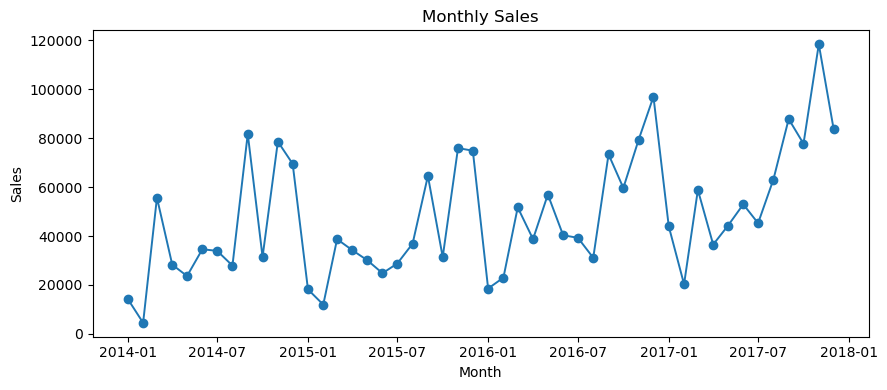

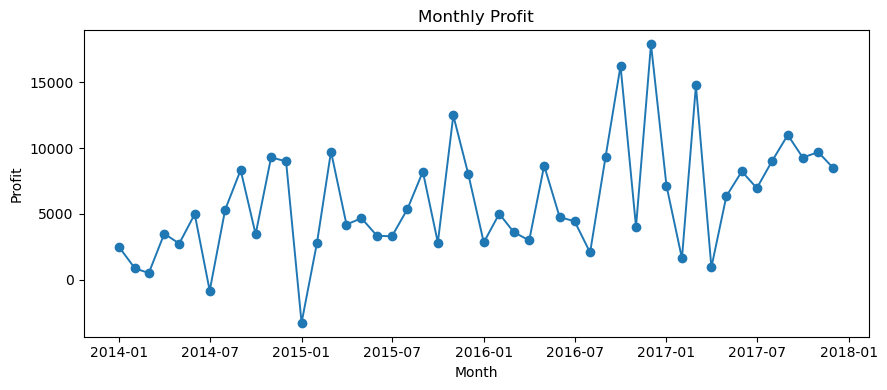

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly["Sales"], marker="o", linewidth=1.4)
ax.set_title("Monthly Sales")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly["Profit"], marker="o", linewidth=1.4)
ax.set_title("Monthly Profit")
ax.set_xlabel("Month")
ax.set_ylabel("Profit")
fig.tight_layout()
plt.show()

**RQ1 evidence:** annual sales increased from approximately $484.2K in 2014 to $733.2K in 2017, while annual profit increased from approximately $49.5K to $93.4K. Monthly results show substantial within-year variation and recurring year-end peaks.

## RQ2 — Product Performance

In [7]:
category_summary = (
    df.groupby("Category")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Quantity=("Quantity", "sum"))
      .sort_values("Profit", ascending=False)
)
category_summary["Profit Margin"] = category_summary["Profit"] / category_summary["Sales"]
category_summary["Profit Share"] = category_summary["Profit"] / total_profit

product_summary = (
    df.groupby(["Product ID", "Product Name"], as_index=False)
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Quantity=("Quantity", "sum"))
)
product_summary["Profit Margin"] = product_summary["Profit"] / product_summary["Sales"]

subcategory_summary = (
    df.groupby("Sub-Category")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
)
subcategory_summary["Profit Margin"] = subcategory_summary["Profit"] / subcategory_summary["Sales"]

top5_products = product_summary.nlargest(5, "Profit")
bottom5_products = product_summary.nsmallest(5, "Profit")
negative_subcategories = subcategory_summary[subcategory_summary["Profit"] < 0].sort_values("Profit")

display(category_summary.round(4))
display(top5_products.round(4))
display(bottom5_products.round(4))
display(negative_subcategories.round(4))

,Sales,Profit,Quantity,Profit Margin,Profit Share
Category,,,,,
Technology,836154.0330,145454.9481,6939,0.1740,0.5079
Office Supplies,719047.0320,122490.8008,22906,0.1704,0.4277
Furniture,741999.7953,18451.2728,8028,0.0249,0.0644


,Product ID,Product Name,Sales,Profit,Quantity,Profit Margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,0.4091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31,0.2824
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,0.3707
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,0.3934
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12,0.2229


,Product ID,Product Name,Sales,Profit,Quantity,Profit Margin
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,-0.8000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,-0.2727
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,-0.4800
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27,-0.2900
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33,-0.2027


,Sales,Profit,Profit Margin
Sub-Category,,,
Tables,206965.5320,-17725.4811,-0.0856
Bookcases,114879.9963,-3472.5560,-0.0302
Supplies,46673.5380,-1189.0995,-0.0255


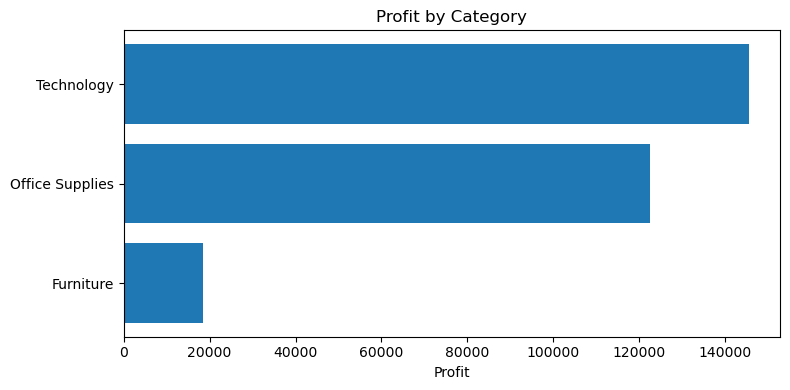

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(category_summary.index[::-1], category_summary["Profit"][::-1])
ax.set_title("Profit by Category")
ax.set_xlabel("Profit")
fig.tight_layout()
plt.show()

**RQ2 evidence:** Technology contributes about $145.5K of profit (50.8% of total profit), while Furniture contributes about $18.5K at a 2.5% margin. Tables, Bookcases, and Supplies are negative-profit sub-categories.

## RQ3 — Geographic Performance

In [9]:
region_summary = (
    df.groupby("Region")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique"))
      .sort_values("Profit", ascending=False)
)
region_summary["Profit Margin"] = region_summary["Profit"] / region_summary["Sales"]

state_summary = (
    df.groupby("State")
      .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique"))
)
state_summary["Profit Margin"] = state_summary["Profit"] / state_summary["Sales"]

display(region_summary.round(4))
display(state_summary.nsmallest(5, "Profit").round(4))
display(state_summary.nlargest(10, "Profit Margin").round(4))

,Sales,Profit,Orders,Profit Margin
Region,,,,
West,725457.8245,108418.4489,1611,0.1494
East,678781.2400,91522.7800,1401,0.1348
South,391721.9050,46749.4303,822,0.1193
Central,501239.8908,39706.3625,1175,0.0792


,Sales,Profit,Orders,Profit Margin
State,,,,
Texas,170188.0458,-25729.3563,487,-0.1512
Ohio,78258.1360,-16971.3766,236,-0.2169
Pennsylvania,116511.9140,-15559.9603,288,-0.1335
Illinois,80166.1010,-12607.8870,276,-0.1573
North Carolina,55603.1640,-7490.9122,136,-0.1347


,Sales,Profit,Orders,Profit Margin
State,,,,
District of Columbia,2865.020,1059.5893,4,0.3698
Delaware,27451.069,9977.3748,44,0.3635
Minnesota,29863.150,10823.1874,44,0.3624
Maine,1270.530,454.4862,3,0.3577
Arkansas,11678.130,4008.6871,27,0.3433
Indiana,53555.360,18382.9363,73,0.3433
Georgia,49095.840,16250.0433,91,0.3310
Montana,5589.352,1833.3285,8,0.3280
Rhode Island,22627.956,7285.6293,25,0.3220


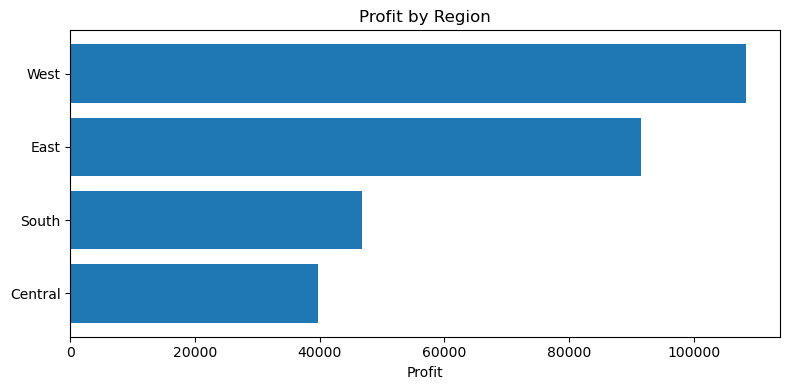

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(region_summary.index[::-1], region_summary["Profit"][::-1])
ax.set_title("Profit by Region")
ax.set_xlabel("Profit")
fig.tight_layout()
plt.show()

**RQ3 evidence:** West records about $108.4K profit at a 14.9% margin, while Central records about $39.7K profit at a 7.9% margin. State-level results show that high sales volume does not guarantee positive profitability; Texas and Ohio are examples of negative-profit states.

## RQ4 — Customer Performance

In [11]:
segment_summary = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Customers=("Customer ID", "nunique"),
      )
)
segment_summary["Profit Margin"] = segment_summary["Profit"] / segment_summary["Sales"]
segment_summary["Average Order Value"] = segment_summary["Sales"] / segment_summary["Orders"]
segment_summary["Order Share"] = segment_summary["Orders"] / total_orders

display(segment_summary.round(4))

,Sales,Profit,Orders,Customers,Profit Margin,Average Order Value,Order Share
Segment,,,,,,,
Consumer,1.161401e+06,134119.2092,2586,409,0.1155,449.1111,0.5163
Corporate,7.061464e+05,91979.1340,1514,236,0.1303,466.4111,0.3023
Home Office,4.296531e+05,60298.6785,909,148,0.1403,472.6657,0.1815


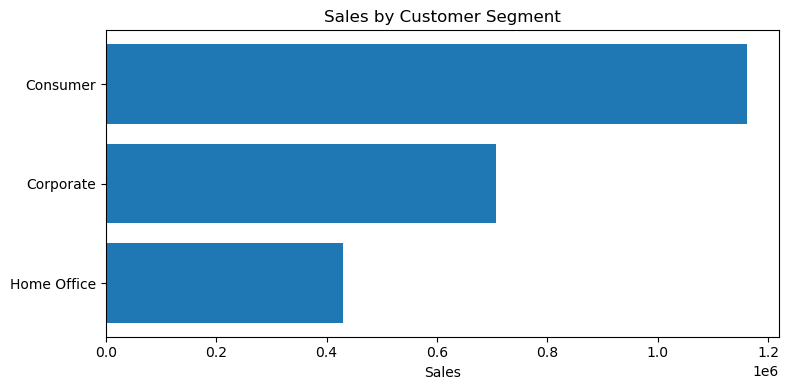

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(segment_summary.index[::-1], segment_summary["Sales"][::-1])
ax.set_title("Sales by Customer Segment")
ax.set_xlabel("Sales")
fig.tight_layout()
plt.show()

**RQ4 evidence:** Consumer customers account for about 51.6% of distinct orders and approximately $1.16M in sales. Home Office has the highest segment margin (14.0%) and average order value ($472.67).

## RQ5 — Discounting and Profitability

In [13]:
discount_distribution = (
    df.groupby("Discount")
      .agg(Order_Lines=("Row ID", "size"), Profit=("Profit", "sum"), Sales=("Sales", "sum"))
      .sort_index()
)
discount_distribution["Profit Margin"] = discount_distribution["Profit"] / discount_distribution["Sales"]

display(discount_distribution.round(4))

pearson_r, pearson_p = pearsonr(df["Discount"], df["Profit"])
spearman_rho, spearman_p = spearmanr(df["Discount"], df["Profit"])

print(f"Pearson r    = {pearson_r:.3f} (p < 0.001)")
print(f"Spearman rho = {spearman_rho:.3f} (p < 0.001)")

,Order_Lines,Profit,Sales,Profit Margin
Discount,,,,
0.00,4798,320987.6032,1.087908e+06,0.2951
0.10,94,9029.1770,5.436935e+04,0.1661
0.15,52,1418.9915,2.755852e+04,0.0515
0.20,3657,90337.3060,7.645944e+05,0.1182
0.30,227,-10369.2774,1.032267e+05,-0.1005
0.32,27,-2391.1377,1.449346e+04,-0.1650
0.40,206,-23057.0504,1.164178e+05,-0.1981
0.45,11,-2493.1111,5.484974e+03,-0.4545
0.50,66,-20506.4281,5.891854e+04,-0.3480


Pearson r    = -0.219 (p < 0.001)
Spearman rho = -0.543 (p < 0.001)


In [14]:
adjustment_cols = ["Quantity", "Category", "Sub-Category", "Region", "Segment"]
categorical_cols = ["Category", "Sub-Category", "Region", "Segment"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("numeric", "passthrough", ["Quantity"]),
    ]
)

X_cov = preprocessor.fit_transform(df[adjustment_cols])

discount_model = LinearRegression().fit(X_cov, df["Discount"])
profit_model = LinearRegression().fit(X_cov, df["Profit"])

df["Discount_Adjusted"] = df["Discount"] - discount_model.predict(X_cov)
df["Profit_Adjusted"] = df["Profit"] - profit_model.predict(X_cov)

X_reg = pd.DataFrame(
    X_cov.toarray() if hasattr(X_cov, "toarray") else X_cov,
    index=df.index,
)
X_reg["Discount"] = df["Discount"]
X_reg = sm.add_constant(X_reg, has_constant="add")

adjusted_model = sm.OLS(df["Profit"], X_reg).fit(cov_type="HC3")

beta = adjusted_model.params["Discount"]
hc3_se = adjusted_model.bse["Discount"]
p_value = adjusted_model.pvalues["Discount"]
ci_low, ci_high = adjusted_model.conf_int().loc["Discount"]

rq5_results = pd.Series({
    "Pearson r": pearson_r,
    "Spearman rho": spearman_rho,
    "Adjusted beta": beta,
    "HC3 Robust SE": hc3_se,
    "p-value": p_value,
    "CI low": ci_low,
    "CI high": ci_high,
    "N": len(df),
})

display(rq5_results.to_frame("Value"))

,Value
Pearson r,-2.194875e-01
Spearman rho,-5.433502e-01
Adjusted beta,-3.382075e+02
HC3 Robust SE,2.225998e+01
p-value,3.903768e-52
CI low,-3.818363e+02
CI high,-2.945788e+02
N,9.994000e+03


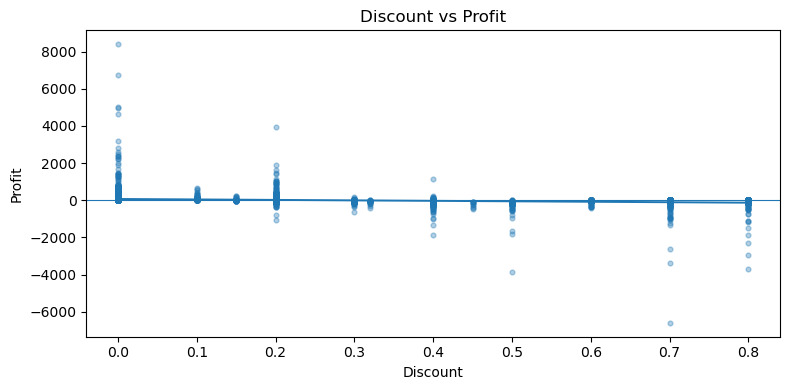

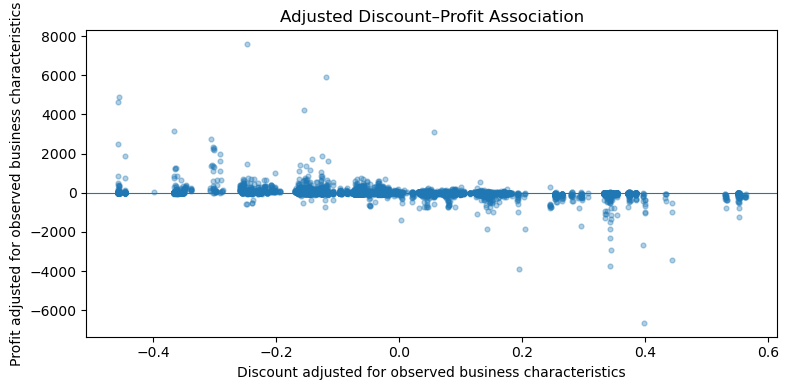

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df["Discount"], df["Profit"], s=12, alpha=0.35)
coef = np.polyfit(df["Discount"], df["Profit"], 1)
x_grid = np.linspace(df["Discount"].min(), df["Discount"].max(), 200)
ax.plot(x_grid, coef[0] * x_grid + coef[1], linewidth=1.4)
ax.axhline(0, linewidth=0.8)
ax.set_title("Discount vs Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df["Discount_Adjusted"], df["Profit_Adjusted"], s=12, alpha=0.35)
ax.axhline(0, linewidth=0.8)
ax.set_title("Adjusted Discount–Profit Association")
ax.set_xlabel("Discount adjusted for observed business characteristics")
ax.set_ylabel("Profit adjusted for observed business characteristics")
fig.tight_layout()
plt.show()

**RQ5 evidence:** Pearson r = −0.219 and Spearman ρ = −0.543. The adjusted OLS coefficient for Discount is −338.21 with HC3 SE 22.26 and 95% CI [−381.84, −294.58]. These are observational associations, not causal effects.

## 4. Compact Output Export

In [16]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

annual.to_csv(TABLE_DIR / "annual_performance.csv")
monthly.to_csv(TABLE_DIR / "monthly_performance.csv")
category_summary.to_csv(TABLE_DIR / "category_performance.csv")
subcategory_summary.to_csv(TABLE_DIR / "subcategory_performance.csv")
region_summary.to_csv(TABLE_DIR / "region_performance.csv")
state_summary.to_csv(TABLE_DIR / "state_performance.csv")
segment_summary.to_csv(TABLE_DIR / "customer_segment_performance.csv")
top5_products.to_csv(TABLE_DIR / "top5_products_by_profit.csv", index=False)
bottom5_products.to_csv(TABLE_DIR / "bottom5_products_by_profit.csv", index=False)
discount_distribution.to_csv(TABLE_DIR / "discount_distribution.csv")

print(f"Tables saved to: {TABLE_DIR.resolve()}")

Tables saved to: C:\Users\farra\OneDrive\Documents\Portfolio Projects\Sales Performance Dashboard\outputs\tables


## 5. Final Analytical Check

In [17]:
final_check = {
    "Rows": len(df),
    "Distinct Orders": df["Order ID"].nunique(),
    "Unique Customers": df["Customer ID"].nunique(),
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Quantity": df["Quantity"].sum(),
}

display(pd.Series(final_check, name="Value").to_frame())

assert final_check["Rows"] == 9_994
assert final_check["Distinct Orders"] == 5_009
assert final_check["Unique Customers"] == 793
assert np.isclose(final_check["Total Sales"], 2_297_200.8603, atol=0.01)
assert np.isclose(final_check["Total Profit"], 286_397.0217, atol=0.01)
assert final_check["Total Quantity"] == 37_873

print("FINAL ANALYTICAL CHECK: PASSED")

,Value
Rows,9.994000e+03
Distinct Orders,5.009000e+03
Unique Customers,7.930000e+02
Total Sales,2.297201e+06
Total Profit,2.863970e+05
Total Quantity,3.787300e+04


FINAL ANALYTICAL CHECK: PASSED
